## K Means

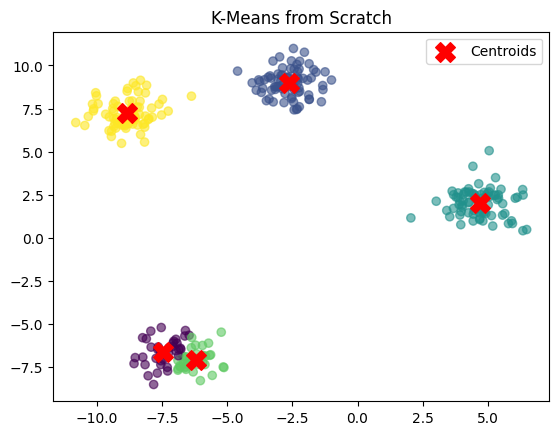

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class KMeansFromScratch:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        
    def fit(self, X):
        n_samples, n_features = X.shape
        # 1. Initialize centroids randomly from data points
        random_idxs = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_idxs]
        
        for _ in range(self.max_iters):
            # 2. Assignment step: find closest centroid for each point
            distances = self._compute_distances(X)
            labels = np.argmin(distances, axis=1)
            
            # 3. Update step: calculate new centroids (means)
            new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(self.k)])
            
            # 4. Convergence check
            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break
                
            self.centroids = new_centroids
            
        self.labels_ = labels
        return self
        
    def _compute_distances(self, X):
        # Calculate Euclidean distances using broadcasting
        # Shape: (n_samples, k)
        return np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)

    def predict(self, X):
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

# Quick Test
if __name__ == "__main__":
    from sklearn.datasets import make_blobs
    X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
    
    kmeans = KMeansFromScratch(k=5)
    kmeans.fit(X)
    
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.6)
    plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], color='red', marker='X', s=200, label='Centroids')
    plt.title("K-Means from Scratch")
    plt.legend()
    # plt.show()

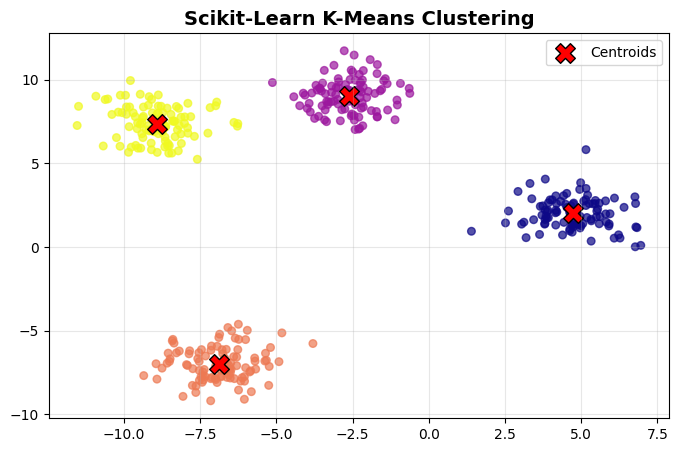

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate Synthetic Data
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=1.0, random_state=42)

# 2. Fit the Model
# n_init='auto' suppresses a warning and runs the optimal initialization scheme
kmeans_sklearn = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans_sklearn.fit(X)

# 3. Extract parameters
labels = kmeans_sklearn.labels_
centroids = kmeans_sklearn.cluster_centers_

# 4. Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=30, alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black', label='Centroids')
plt.title("Scikit-Learn K-Means Clustering", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('kmeans_sklearn.png', dpi=150)
# plt.show()


--- Marketing Strategy based on Segments ---
Target High Income / High Spend clusters with luxury items.
Target Mid Income / Mid Spend with volume discounts.
Investigate High Income / Low Spend to see why they aren't purchasing more.


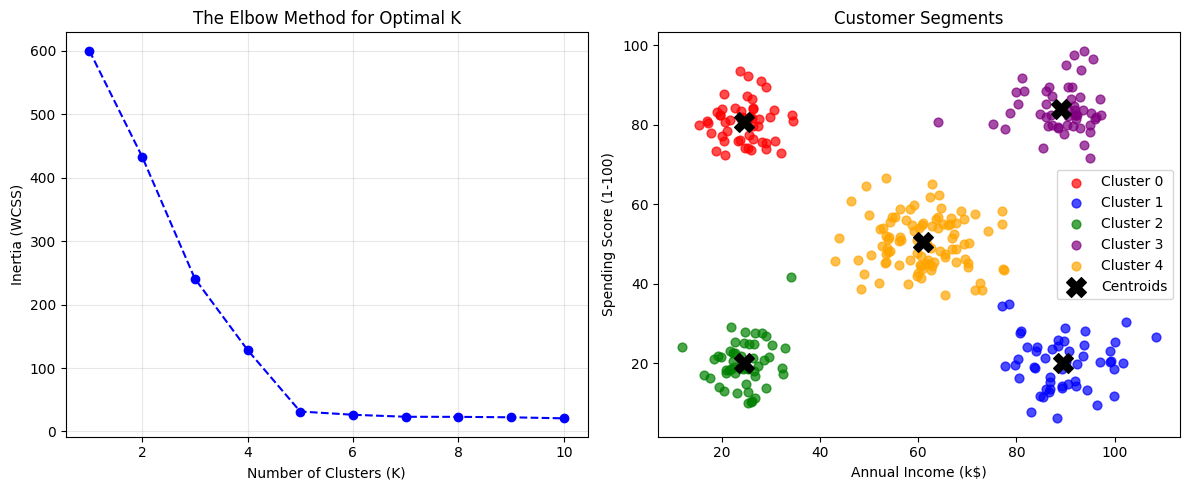

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Synthesize Customer Data
np.random.seed(42)
# Creating 5 distinct customer profiles
n = 50
c1 = np.random.normal(loc=[25, 20], scale=[5, 5], size=(n, 2))  # Low Income, Low Spend
c2 = np.random.normal(loc=[25, 80], scale=[5, 5], size=(n, 2))  # Low Income, High Spend
c3 = np.random.normal(loc=[60, 50], scale=[8, 8], size=(n*2, 2))# Mid Income, Mid Spend (Core customers)
c4 = np.random.normal(loc=[90, 20], scale=[6, 6], size=(n, 2))  # High Income, Low Spend
c5 = np.random.normal(loc=[90, 85], scale=[6, 6], size=(n, 2))  # High Income, High Spend

data = np.vstack((c1, c2, c3, c4, c5))
df = pd.DataFrame(data, columns=['Annual_Income', 'Spending_Score'])

# 2. Preprocessing (Standardization is crucial for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. Determine Optimal K using the Elbow Method
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o', linestyle='--', color='blue')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True, alpha=0.3)

# 4. Train Final Model (K=5 looks like a good elbow)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Inverse transform centroids back to original scale for interpretation
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# 5. Visualize the Segments
plt.subplot(1, 2, 2)
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual_Income'], cluster_data['Spending_Score'], 
                s=40, c=colors[i], label=f'Cluster {i}', alpha=0.7)

plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.savefig('customer_segmentation.png', dpi=150)
# plt.show()

print("\n--- Marketing Strategy based on Segments ---")
print("Target High Income / High Spend clusters with luxury items.")
print("Target Mid Income / Mid Spend with volume discounts.")
print("Investigate High Income / Low Spend to see why they aren't purchasing more.")

## Hierarchical

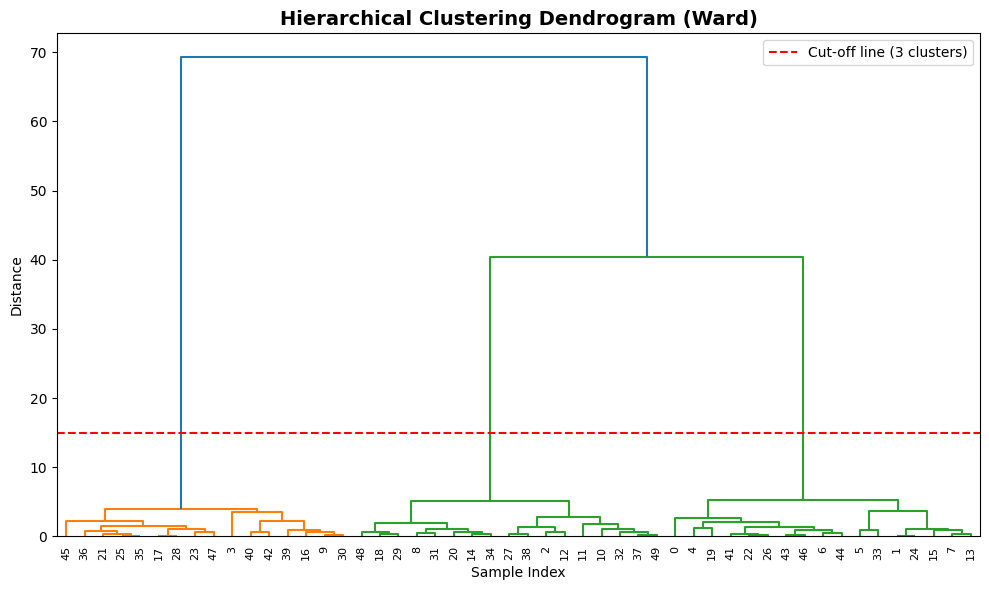

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs

# 1. Generate Data
X, _ = make_blobs(n_samples=50, centers=3, cluster_std=1.0, random_state=42)

# 2. Perform Hierarchical/Agglomerative Clustering
# The linkage() function returns an (N-1) x 4 matrix Z.
# Z[i] tells us which clusters were merged at step i, the distance between them, and number of original observations.
Z = linkage(X, method='ward', metric='euclidean')

# 3. Plot the Dendrogram
plt.figure(figsize=(10, 6))
plt.title('Hierarchical Clustering Dendrogram (Ward)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Distance')

# Draw the dendrogram
dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
)

# Draw a cut-off line
plt.axhline(y=15, color='r', linestyle='--', label='Cut-off line (3 clusters)')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
# plt.show()

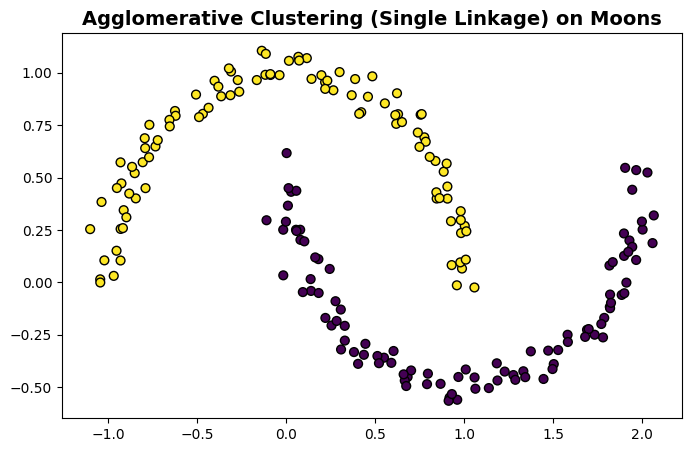

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_moons

# Let's try it on non-spherical data!
X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

# Single Linkage is actually good at following chains (like moons)
agg_cluster = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg_cluster.fit_predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, edgecolors='k')
plt.title("Agglomerative Clustering (Single Linkage) on Moons", fontsize=14, fontweight='bold')
plt.savefig('agg_moons.png', dpi=150)
# plt.show()

## DBSCAN

Estimated number of clusters: 2
Estimated number of noise points: 0


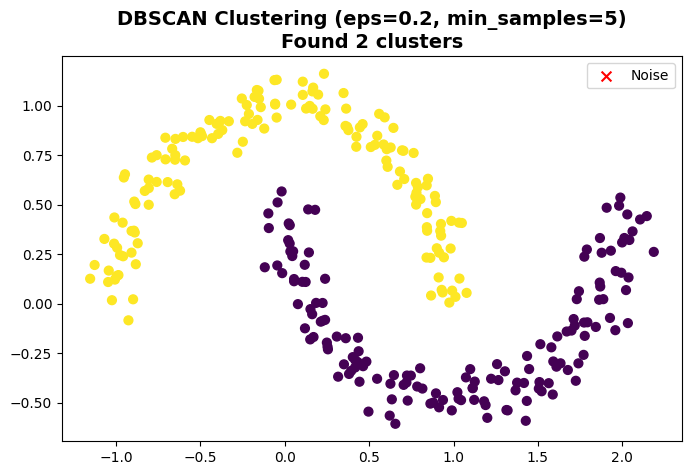

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# 1. Generate Non-Convex Data (Half-Moons)
X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

# 2. Fit DBSCAN
# Note: DBSCAN does not have a predict() method for new data out of the box in sklearn.
# You must use fit_predict() on the entire dataset.
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Labels equal to -1 represent NOISE (Outliers)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

# 3. Visualization
plt.figure(figsize=(8, 5))

# Plot core and border points
scatter = plt.scatter(X[labels != -1, 0], X[labels != -1, 1], c=labels[labels != -1], cmap='viridis', s=40)

# Plot noise points in red
plt.scatter(X[labels == -1, 0], X[labels == -1, 1], c='red', marker='x', s=50, label='Noise')

plt.title(f"DBSCAN Clustering (eps=0.2, min_samples=5)\nFound {n_clusters_} clusters", fontsize=14, fontweight='bold')
plt.legend()
plt.savefig('dbscan_moons.png', dpi=150)
# plt.show()

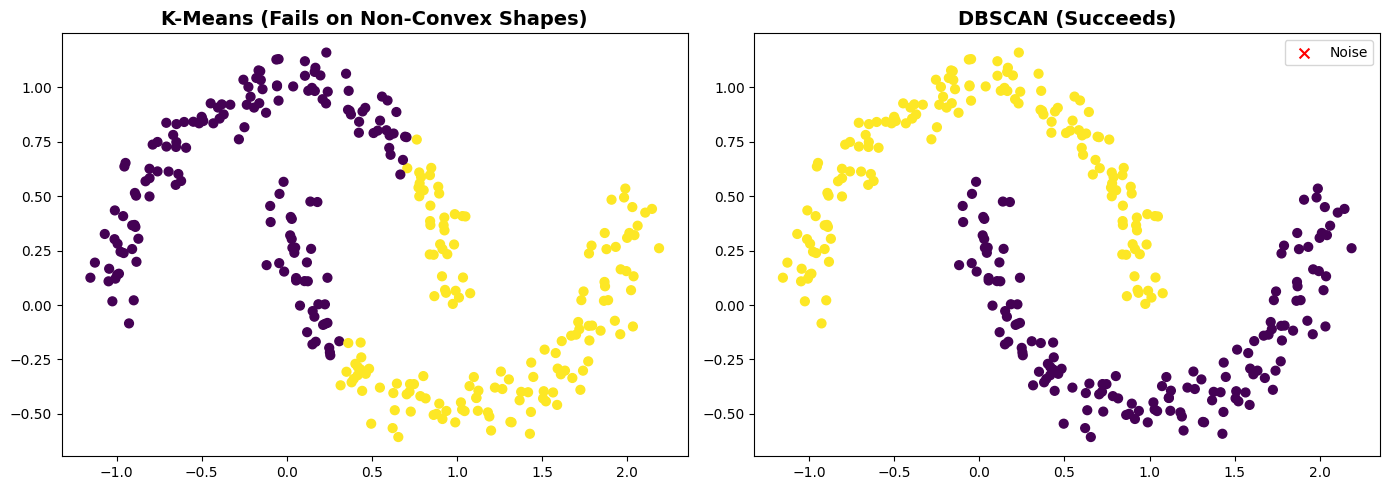

In [7]:
from sklearn.cluster import KMeans

# Fit K-Means on the exact same data
kmeans = KMeans(n_clusters=2, random_state=42)
km_labels = kmeans.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means Plot
axes[0].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='viridis', s=40)
axes[0].set_title('K-Means (Fails on Non-Convex Shapes)', fontsize=14, fontweight='bold')

# DBSCAN Plot
axes[1].scatter(X[labels != -1, 0], X[labels != -1, 1], c=labels[labels != -1], cmap='viridis', s=40)
axes[1].scatter(X[labels == -1, 0], X[labels == -1, 1], c='red', marker='x', s=50, label='Noise')
axes[1].set_title('DBSCAN (Succeeds)', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_vs_dbscan.png', dpi=150)
# plt.show()

## Mean Shift

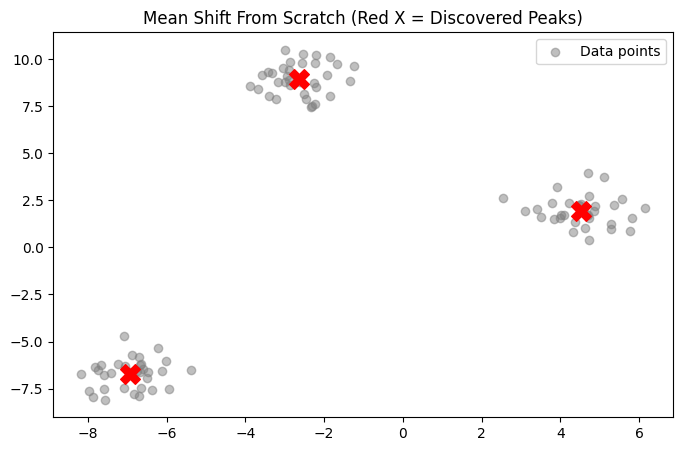

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

class MeanShiftFromScratch:
    def __init__(self, bandwidth=2.0):
        self.bandwidth = bandwidth
        self.centroids = {}

    def fit(self, data):
        # 1. Initialize a window for every single data point
        centroids = {i: list(point) for i, point in enumerate(data)}
        
        while True:
            new_centroids = []
            for i in centroids:
                in_bandwidth = []
                centroid = centroids[i]
                
                # 2. Find all points within the bandwidth
                for feature_set in data:
                    if np.linalg.norm(np.array(feature_set) - np.array(centroid)) < self.bandwidth:
                        in_bandwidth.append(feature_set)
                
                # 3. Calculate new mean and shift
                new_centroid = np.average(in_bandwidth, axis=0)
                new_centroids.append(tuple(new_centroid))
            
            # 4. Filter out duplicate centroids (merge windows that hit the same peak)
            uniques = sorted(list(set(new_centroids)))
            
            prev_centroids = dict(centroids)
            centroids = {i: list(point) for i, point in enumerate(uniques)}
            
            # 5. Check for convergence (if centroids stopped moving)
            optimized = True
            for i in centroids:
                if not np.array_equal(centroids[i], prev_centroids.get(i, [])):
                    optimized = False
                    break
                    
            if optimized:
                break
                
        self.centroids = centroids

# Test the algorithm
X, _ = make_blobs(n_samples=100, centers=3, cluster_std=0.8, random_state=42)
ms = MeanShiftFromScratch(bandwidth=3)
ms.fit(X)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5, label='Data points')
for c in ms.centroids:
    plt.scatter(ms.centroids[c][0], ms.centroids[c][1], color='red', marker='X', s=200)
plt.title("Mean Shift From Scratch (Red X = Discovered Peaks)")
plt.legend()
# plt.show()


Estimated Bandwidth: 1.57
Number of estimated clusters: 4


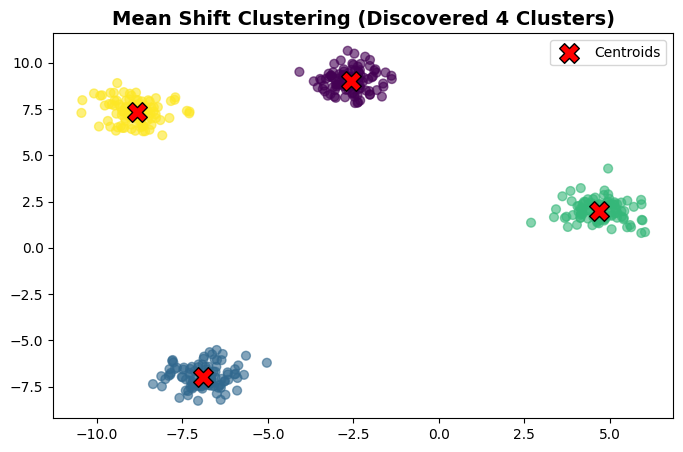

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.datasets import make_blobs

# 1. Generate Data
X, _ = make_blobs(n_samples=400, centers=4, cluster_std=0.6, random_state=42)

# 2. Estimate Bandwidth automatically! (This is a huge advantage)
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=100)
print(f"Estimated Bandwidth: {bandwidth:.2f}")

# 3. Fit Mean Shift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)

labels = ms.labels_
cluster_centers = ms.cluster_centers_
n_clusters_ = len(np.unique(labels))
print(f"Number of estimated clusters: {n_clusters_}")

# 4. Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, alpha=0.6)
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', marker='X', s=200, edgecolors='black', label='Centroids')
plt.title(f"Mean Shift Clustering (Discovered {n_clusters_} Clusters)", fontsize=14, fontweight='bold')
plt.legend()
plt.savefig('mean_shift.png', dpi=150)
# plt.show()

## GMM

Soft Assignments for first 5 points [Prob Cluster 1, Prob Cluster 2]:
[[0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


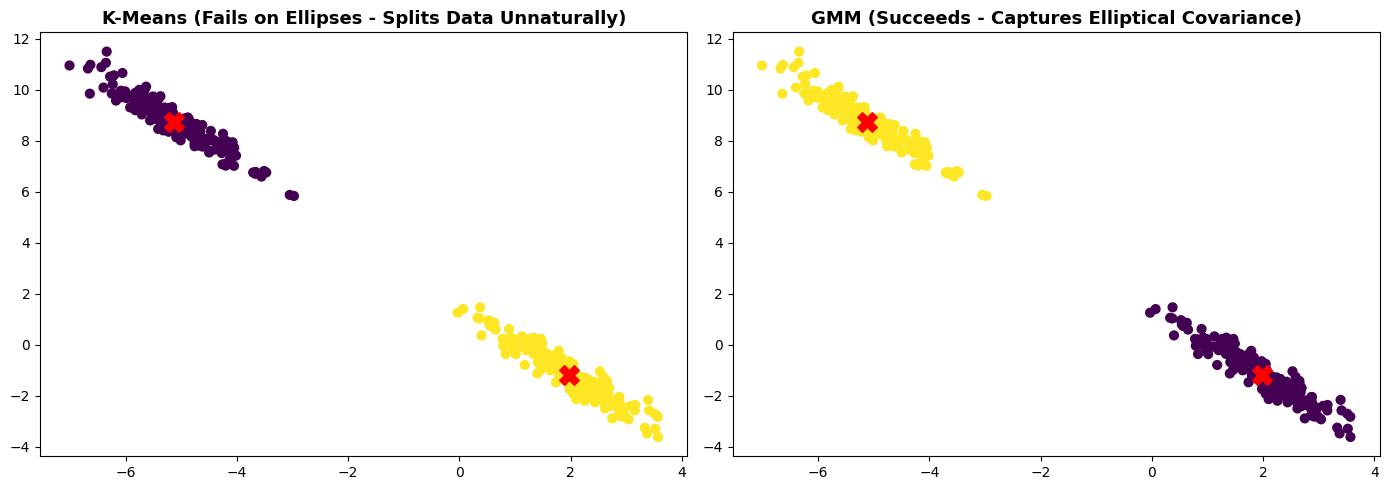

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

# 1. Generate synthetic data and stretch it into ellipses
n_samples = 400
X, y = make_blobs(n_samples=n_samples, centers=2, cluster_std=1.0, random_state=42)
transformation_matrix = np.array([[0.6, -0.6], [-0.4, 0.8]]) # Stretches the data
X_stretched = np.dot(X, transformation_matrix)

# 2. Fit K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
km_labels = kmeans.fit_predict(X_stretched)

# 3. Fit GMM
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_stretched)
gmm_probs = gmm.predict_proba(X_stretched) # This gets the soft assignments!

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means Plot
axes[0].scatter(X_stretched[:, 0], X_stretched[:, 1], c=km_labels, cmap='viridis', s=40)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200)
axes[0].set_title('K-Means (Fails on Ellipses - Splits Data Unnaturally)', fontsize=13, fontweight='bold')

# GMM Plot
# We color by the probability of belonging to cluster 1
axes[1].scatter(X_stretched[:, 0], X_stretched[:, 1], c=gmm_probs[:, 0], cmap='viridis', s=40)
axes[1].scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='red', marker='X', s=200)
axes[1].set_title('GMM (Succeeds - Captures Elliptical Covariance)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('gmm_clustering.png', dpi=150)
# plt.show()

# Show soft probabilities for a few points
print("Soft Assignments for first 5 points [Prob Cluster 1, Prob Cluster 2]:")
print(np.round(gmm_probs[:5], 3))

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

class GMM1D:
    def __init__(self, k, max_iter=50):
        self.k = k
        self.max_iter = max_iter
        
    def fit(self, X):
        n = len(X)
        # 1. Initialize parameters
        self.mu = np.random.choice(X, self.k)
        self.sigma = np.ones(self.k)
        self.pi = np.ones(self.k) / self.k
        self.gamma = np.zeros((n, self.k))
        
        for iteration in range(self.max_iter):
            # E-Step: Calculate Responsibilities
            for j in range(self.k):
                self.gamma[:, j] = self.pi[j] * norm.pdf(X, self.mu[j], self.sigma[j])
            
            # Normalize over rows
            self.gamma = self.gamma / self.gamma.sum(axis=1, keepdims=True)
            
            # M-Step: Update Parameters
            N_k = self.gamma.sum(axis=0)
            
            for j in range(self.k):
                self.mu[j] = np.sum(self.gamma[:, j] * X) / N_k[j]
                self.sigma[j] = np.sqrt(np.sum(self.gamma[:, j] * (X - self.mu[j])**2) / N_k[j])
                self.pi[j] = N_k[j] / n

# Let's test it on a bimodal distribution
np.random.seed(42)
X1 = np.random.normal(loc=20, scale=5, size=300)
X2 = np.random.normal(loc=60, scale=10, size=700)
X = np.concatenate([X1, X2])

gmm1d = GMM1D(k=2)
gmm1d.fit(X)

print(f"True Means: 20, 60 | Estimated Means: {np.round(gmm1d.mu, 2)}")
print(f"True Stds: 5, 10   | Estimated Stds: {np.round(gmm1d.sigma, 2)}")

True Means: 20, 60 | Estimated Means: [nan nan]
True Stds: 5, 10   | Estimated Stds: [nan nan]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19476\1217259684.py:24: RuntimeWarning: invalid value encountered in divide
  self.gamma = self.gamma / self.gamma.sum(axis=1, keepdims=True)


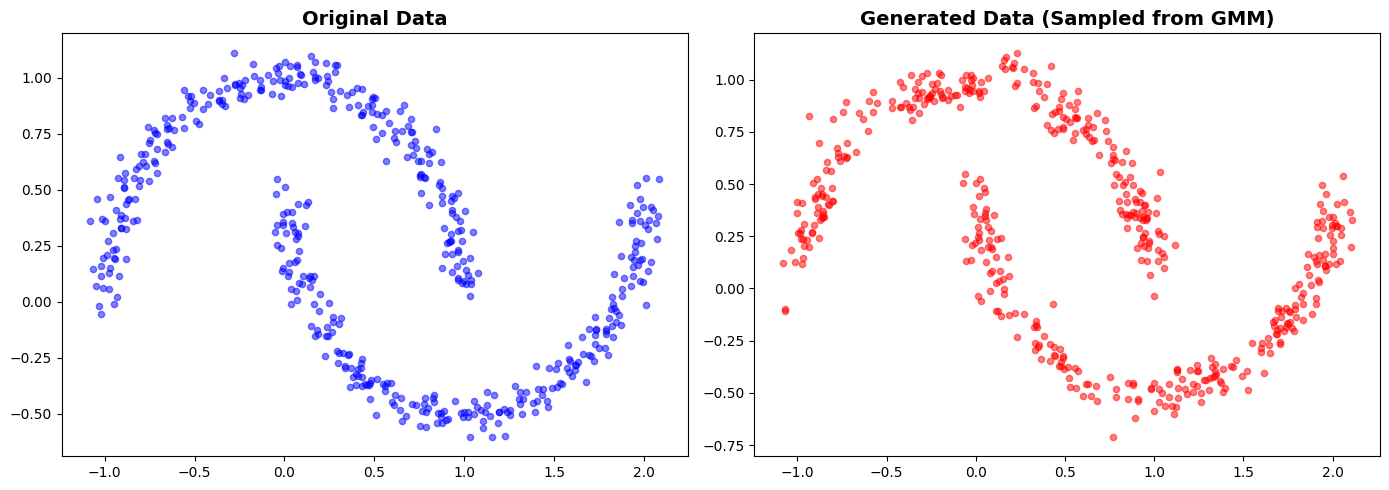

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_moons

# 1. Generate Non-linear Data
X, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

# 2. Fit GMM (We use 10 components to approximate the complex moon shapes)
gmm = GaussianMixture(n_components=10, covariance_type='full', random_state=42)
gmm.fit(X)

# 3. GENERATE new data from the learned distribution!
X_generated, _ = gmm.sample(500)

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X[:, 0], X[:, 1], c='blue', alpha=0.5, s=20)
axes[0].set_title('Original Data', fontsize=14, fontweight='bold')

axes[1].scatter(X_generated[:, 0], X_generated[:, 1], c='red', alpha=0.5, s=20)
axes[1].set_title('Generated Data (Sampled from GMM)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('gmm_generative.png', dpi=150)
# plt.show()

## Dimensionality Reduction & Visualization

In [12]:
import numpy as np
import matplotlib.pyplot as plt

class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        # 1. Mean centering
        self.mean = np.mean(X, axis=0)
        X = X - self.mean

        # 2. Covariance matrix (features x features)
        # np.cov expects features as rows, so we transpose X
        cov_matrix = np.cov(X.T)

        # 3. Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        # 4. Sort eigenvectors by eigenvalues in descending order
        # eigenvectors are returned as columns
        eigenvectors = eigenvectors.T
        idxs = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[idxs]

        # 5. Store first n_components
        self.components = eigenvectors[0:self.n_components]

    def transform(self, X):
        # Project data
        X = X - self.mean
        return np.dot(X, self.components.T)

# Test on 2D -> 1D reduction
np.random.seed(42)
X_test = np.dot(np.random.rand(2, 2), np.random.randn(2, 200)).T

pca = PCAFromScratch(n_components=1)
pca.fit(X_test)
X_projected = pca.transform(X_test)

print(f"Original shape: {X_test.shape}")
print(f"Projected shape: {X_projected.shape}")

Original shape: (200, 2)
Projected shape: (200, 1)


Original Data Shape: (400, 4096)
Compressed Data Shape: (400, 123)
Dimensions reduced from 4096 -> 123 while keeping 95% of variance!


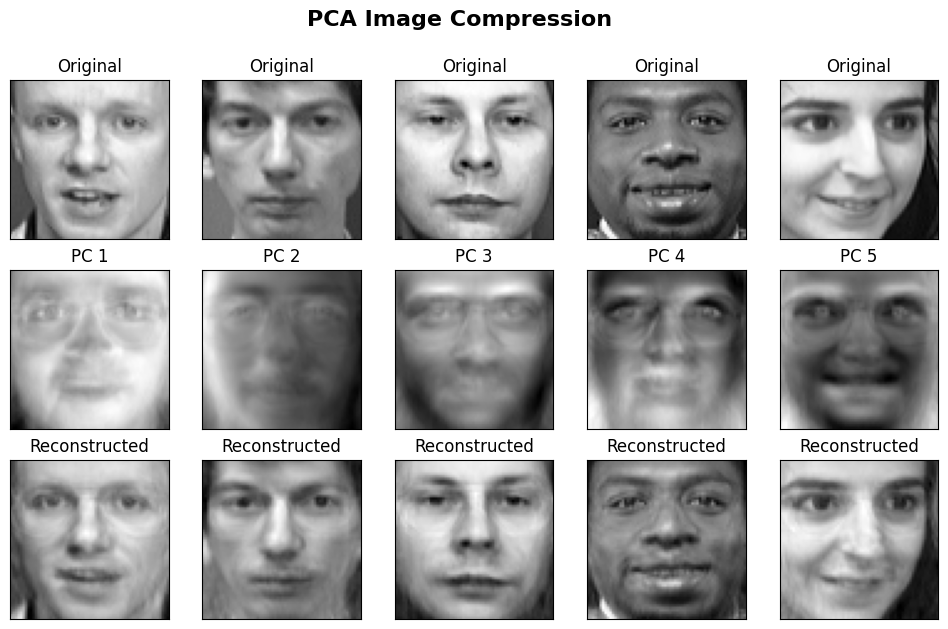

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

# 1. Load Data (400 images, 64x64 pixels = 4096 dimensions)
faces, _ = fetch_olivetti_faces(return_X_y=True, shuffle=True, random_state=42)
print(f"Original Data Shape: {faces.shape}") # (400, 4096)

# 2. Fit PCA to retain 95% of the variance
# Notice we pass a float between 0 and 1! Scikit-learn automatically calculates how many PCs are needed.
pca = PCA(n_components=0.95, random_state=42)
faces_pca = pca.fit_transform(faces)

print(f"Compressed Data Shape: {faces_pca.shape}")
print(f"Dimensions reduced from 4096 -> {pca.n_components_} while keeping 95% of variance!")

# 3. Reconstruct Images (from 123D back to 4096D)
faces_reconstructed = pca.inverse_transform(faces_pca)

# 4. Visualize
fig, axes = plt.subplots(3, 5,figsize=(12, 7),subplot_kw={'xticks': [], 'yticks': []})

for i in range(5):
    axes[0, i].imshow(faces[i].reshape(64, 64), cmap='gray')
    axes[0, i].set_title("Original")

    axes[1, i].imshow(pca.components_[i].reshape(64, 64), cmap='gray')
    axes[1, i].set_title(f"PC {i+1}")

    axes[2, i].imshow(faces_reconstructed[i].reshape(64, 64), cmap='gray')
    axes[2, i].set_title("Reconstructed")

plt.suptitle("PCA Image Compression", fontsize=16, fontweight='bold')
plt.savefig('pca_image_compression.png', dpi=150)
# plt.show()

PCA preserved 0.96% of variance in 30 dims.
t-SNE completed in 7.80 seconds.


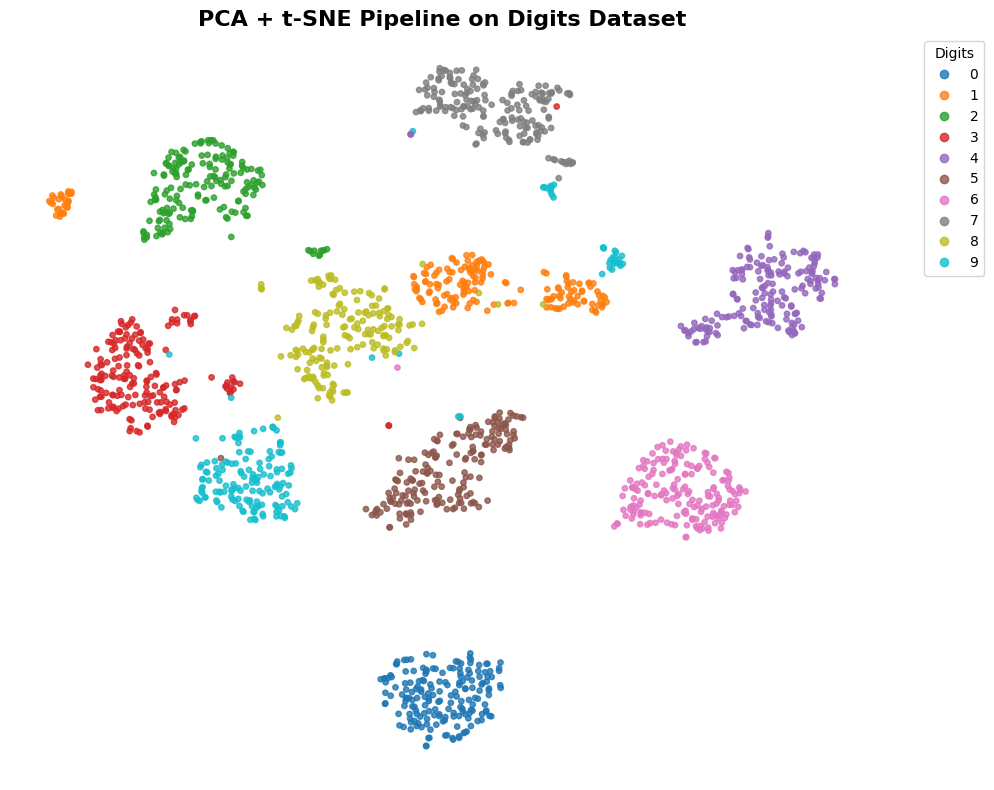

In [19]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import time

# 1. Load Digits Dataset (8x8 images = 64 dimensions)
digits = load_digits()
X, y = digits.data, digits.target

# 2. Step 1: PCA down to 30 dimensions
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X)
print(f"PCA preserved {sum(pca.explained_variance_ratio_):.2f}% of variance in 30 dims.")

# 3. Step 2: t-SNE down to 2 dimensions for visualization
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
t0 = time.time()
X_tsne = tsne.fit_transform(X_pca) # We feed it the PCA output!
print(f"t-SNE completed in {time.time() - t0:.2f} seconds.")

# 4. Visualization
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=15, alpha=0.8)
plt.legend(*scatter.legend_elements(), title="Digits", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("PCA + t-SNE Pipeline on Digits Dataset", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('tsne_pipeline.png', dpi=150)
# plt.show()

## Anomaly Detection

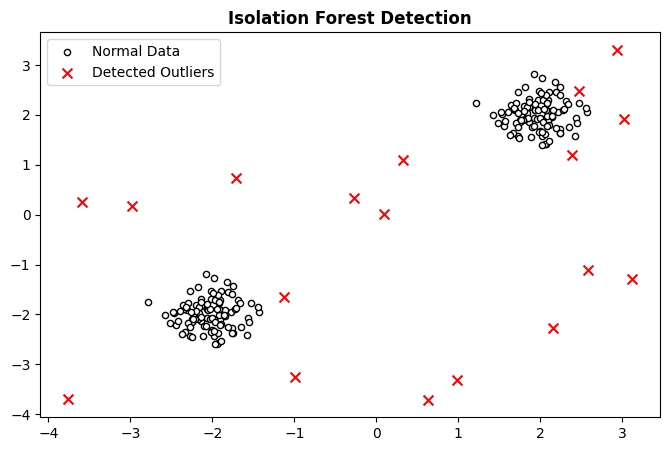

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

np.random.seed(42)
X = 0.3 * np.random.randn(100, 2)
X_train = np.r_[X + 2, X - 2]
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

# Fit the model
clf = IsolationForest(contamination=0.1, random_state=42)
clf.fit(X_train)
y_pred_outliers = clf.predict(X_outliers)

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c='white', s=20, edgecolor='k', label="Normal Data")
plt.scatter(X_outliers[y_pred_outliers==-1, 0], X_outliers[y_pred_outliers==-1, 1], c='red', s=50, marker='x', label="Detected Outliers")
plt.title("Isolation Forest Detection", fontweight='bold')
plt.legend()
# plt.show()

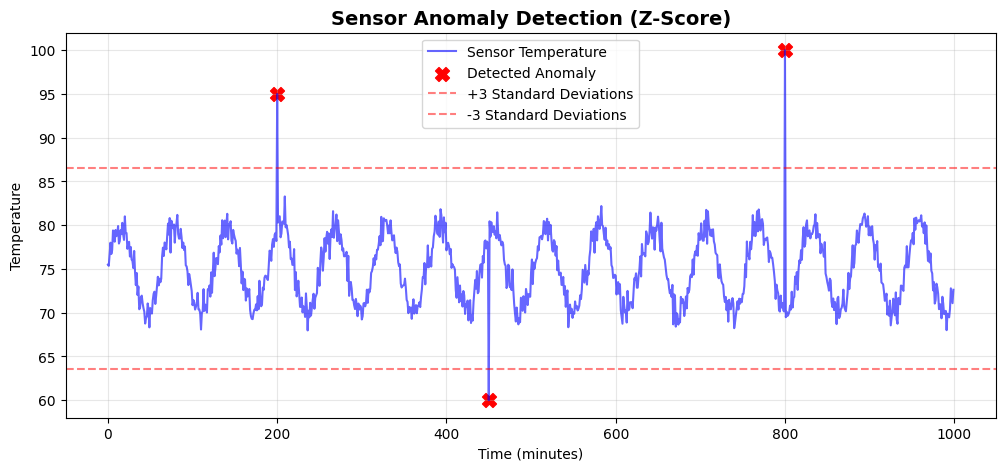

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate Synthetic Time Series Sensor Data
np.random.seed(42)
time = np.arange(0, 1000)
# Normal operating temperature around 75 degrees
temp = 75 + np.sin(time / 10) * 5 + np.random.normal(0, 1, 1000)

# 2. Inject Anomalies (sudden spikes)
temp[200] = 95
temp[450] = 60
temp[800] = 100

# 3. Z-Score Anomaly Detection
mean_temp = np.mean(temp)
std_temp = np.std(temp)

# Calculate Z-scores
z_scores = (temp - mean_temp) / std_temp

# Flag anomalies (Z-score > 3 or < -3)
threshold = 3
anomalies = np.where(np.abs(z_scores) > threshold)[0]

# 4. Visualization
plt.figure(figsize=(12, 5))
plt.plot(time, temp, label='Sensor Temperature', color='blue', alpha=0.6)
plt.scatter(time[anomalies], temp[anomalies], color='red', marker='X', s=100, label='Detected Anomaly')
plt.axhline(mean_temp + threshold*std_temp, color='red', linestyle='--', alpha=0.5, label='+3 Standard Deviations')
plt.axhline(mean_temp - threshold*std_temp, color='red', linestyle='--', alpha=0.5, label='-3 Standard Deviations')

plt.title('Sensor Anomaly Detection (Z-Score)', fontsize=14, fontweight='bold')
plt.xlabel('Time (minutes)')
plt.ylabel('Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('sensor_anomaly.png', dpi=150)
# plt.show()

Total Transactions: 1020
Detected Fraudulent Transactions: 21


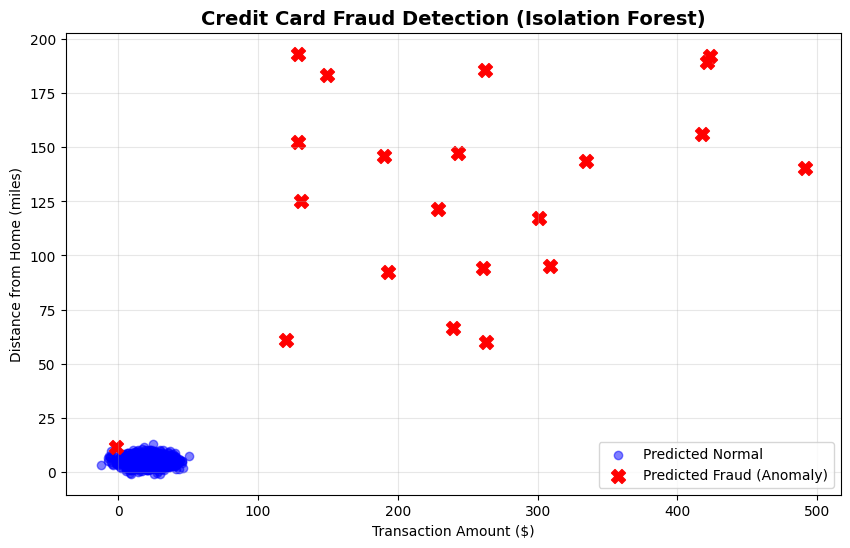

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Generate Synthetic Transaction Data
np.random.seed(42)
# Normal transactions: small amounts, close distance
normal_transactions = np.random.normal(loc=[20, 5], scale=[10, 2], size=(1000, 2))

# Fraudulent transactions: large amounts, far distance
fraud_transactions = np.random.uniform(low=[100, 50], high=[500, 200], size=(20, 2))

# Combine dataset
X = np.vstack((normal_transactions, fraud_transactions))

# 2. Train Isolation Forest
# We expect about 2% of our data to be fraud (contamination)
iso_forest = IsolationForest(contamination=0.02, random_state=42)
preds = iso_forest.fit_predict(X)

# 3. Filter results
# Isolation forest returns 1 for normal, -1 for anomaly
detected_normal = X[preds == 1]
detected_fraud = X[preds == -1]

# 4. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(detected_normal[:, 0], detected_normal[:, 1], c='blue', alpha=0.5, label='Predicted Normal')
plt.scatter(detected_fraud[:, 0], detected_fraud[:, 1], c='red', marker='X', s=100, label='Predicted Fraud (Anomaly)')

plt.title('Credit Card Fraud Detection (Isolation Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Distance from Home (miles)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('fraud_anomaly.png', dpi=150)
# plt.show()

print(f"Total Transactions: {len(X)}")
print(f"Detected Fraudulent Transactions: {len(detected_fraud)}")